In [1]:
# ==========================================
# MODELO 2: MOBILENETV3-LARGE (Local)
# ==========================================
import os
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import layers, models, applications
from sklearn.metrics import classification_report, confusion_matrix

sns.set_theme(style="whitegrid")

# RUTA LOCAL FIJA (Evita problemas de variables de entorno)
BASE_DIR = r'C:\Users\bner\Documents\ues\ML\Proyecto\maize_dataset\clean'

# Configuramos la carpeta de guardado para la versión Large
CARPETA_DESTINO = 'modelos_locales'
os.makedirs(CARPETA_DESTINO, exist_ok=True)
ruta_large = os.path.join(CARPETA_DESTINO, 'mobilenetv3_large_mejor.keras')

if os.path.exists(BASE_DIR):
    class_names = [d for d in sorted(os.listdir(BASE_DIR)) if os.path.isdir(os.path.join(BASE_DIR, d))]
    print(f" Ruta encontrada: {BASE_DIR}")
    print(f" Clases detectadas ({len(class_names)}): {class_names}")
    print(f" El modelo se guardará en: {ruta_large}")
else:
    print(f" Error: No se encontró la ruta {BASE_DIR}. Verifica que sea correcta.")

 Ruta encontrada: C:\Users\bner\Documents\ues\ML\Proyecto\maize_dataset\clean
 Clases detectadas (9): ['aphids_pest', 'common_rust', 'fall_armyworm', 'gray_leaf_spot', 'healthy', 'nitrogen_deficiency', 'northern_corn_leaf_blight', 'phosphorus_deficiency', 'potassium_deficiency']
 El modelo se guardará en: modelos_locales\mobilenetv3_large_mejor.keras


In [2]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f" ¡Excelente! GPU detectada: {gpus}")
else:
    print(" ADVERTENCIA: No se detectó GPU. El entrenamiento usará el CPU y será más lento.")

 ADVERTENCIA: No se detectó GPU. El entrenamiento usará el CPU y será más lento.


In [3]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

print("Cargando y dividiendo el dataset automáticamente...")

train_dataset_raw = tf.keras.utils.image_dataset_from_directory(
    BASE_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

val_test_dataset = tf.keras.utils.image_dataset_from_directory(
    BASE_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

val_batches = tf.data.experimental.cardinality(val_test_dataset)
val_dataset = val_test_dataset.take(val_batches // 2)
test_dataset = val_test_dataset.skip(val_batches // 2)

# Protección de RAM activa (sin caché y shuffle bajo)
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset_raw.shuffle(300).prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

print(f"\n Conjuntos de datos listos.")

Cargando y dividiendo el dataset automáticamente...
Found 25284 files belonging to 9 classes.
Using 20228 files for training.
Found 25284 files belonging to 9 classes.
Using 5056 files for validation.

 Conjuntos de datos listos.


In [4]:
print("Calculando desbalance de forma optimizada en memoria...")

y_train_indices = np.concatenate([np.argmax(y.numpy(), axis=1) for x, y in train_dataset_raw], axis=0)

pesos = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_indices),
    y=y_train_indices
)
class_weights_dict = dict(enumerate(pesos))

print("\nPesos de compensación generados:")
for idx, clase in enumerate(class_names):
    print(f" - {clase}: {class_weights_dict[idx]:.4f}")

Calculando desbalance de forma optimizada en memoria...

Pesos de compensación generados:
 - aphids_pest: 38.7510
 - common_rust: 1.2175
 - fall_armyworm: 0.5799
 - gray_leaf_spot: 2.5140
 - healthy: 0.3199
 - nitrogen_deficiency: 5.5771
 - northern_corn_leaf_blight: 0.4146
 - phosphorus_deficiency: 4.5497
 - potassium_deficiency: 10.6519


In [5]:
# 1. Aumentos de datos (Incluye brillo aleatorio)
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal_and_vertical"),
  layers.RandomRotation(0.2),
  layers.RandomZoom(0.2),
  layers.RandomContrast(0.2),
  layers.RandomBrightness(0.2), 
], name="data_augmentation_layer")

# 2. Cargar modelo base LARGE
base_model_large = applications.MobileNetV3Large(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet',
    include_preprocessing=True
)

# 3. FINE-TUNING (Descongelamos las últimas 20 capas)
base_model_large.trainable = True
for layer in base_model_large.layers[:-20]:
    layer.trainable = False

# 4. Ensamblamos la red
inputs = tf.keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = base_model_large(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x) 

num_clases = len(class_names)
outputs = layers.Dense(num_clases, activation='softmax', name='pred_large')(x)

model_large = tf.keras.Model(inputs, outputs)

# 5. Compilación
model_large.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), 
    loss='categorical_crossentropy', 
    metrics=['accuracy', tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')]
)

print(f"✅ Arquitectura Large construida para {num_clases} clases. Resumen:")
model_large.summary()

12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
✅ Arquitectura Large construida para 9 clases. Resumen:


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation_layer         │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Large (Functional)   │ (None, 7, 7, 960)      │     2,996,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 960)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 960)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pred_large (Dense)              │ (None, 9)              │         8,649 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,005,001 (11.46 MB)

 Trainable params: 961,849 (3.67 MB)

 Non-trainable params: 2,043,152 (7.79 MB)

In [6]:
EPOCHS = 25 

# Callbacks de protección y guardado
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    ruta_large,
    save_best_only=True,
    monitor='val_loss',
    mode='min',
    verbose=1
)

early_stopping_cb = tf.keras.callbacks.EarlyStopping(
    patience=6,
    restore_best_weights=True,
    monitor='val_loss'
)

reduce_lr_cb = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

print(f"\n🚀 ¡Iniciando el entrenamiento de la versión Large!")
history_large = model_large.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    class_weight=class_weights_dict,
    callbacks=[checkpoint_cb, early_stopping_cb, reduce_lr_cb]
)

print(f"\n Entrenamiento finalizado. El mejor modelo se guardó en: {ruta_large}")


🚀 ¡Iniciando el entrenamiento de la versión Large!
Epoch 1/25
633/633 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step - accuracy: 0.6401 - loss: 1.1009 - precision: 0.7697 - recall: 0.5013
Epoch 1: val_loss improved from None to 0.99831, saving model to modelos_locales\mobilenetv3_large_mejor.keras

Epoch 1: finished saving model to modelos_locales\mobilenetv3_large_mejor.keras
633/633 ━━━━━━━━━━━━━━━━━━━━ 221s 326ms/step - accuracy: 0.7708 - loss: 0.7177 - precision: 0.8641 - recall: 0.6818 - val_accuracy: 0.8081 - val_loss: 0.9983 - val_precision: 0.8095 - val_recall: 0.8050 - learning_rate: 5.0000e-04
Epoch 2/25
633/633 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step - accuracy: 0.8808 - loss: 0.3782 - precision: 0.9123 - recall: 0.8550
Epoch 2: val_loss improved from 0.99831 to 0.41932, saving model to modelos_locales\mobilenetv3_large_mejor.keras

Epoch 2: finished saving model to modelos_locales\mobilenetv3_large_mejor.keras
633/633 ━━━━━━━━━━━━━━━━━━━━ 205s 313ms/step - accuracy: 0.8902 - loss: 0.3594 -

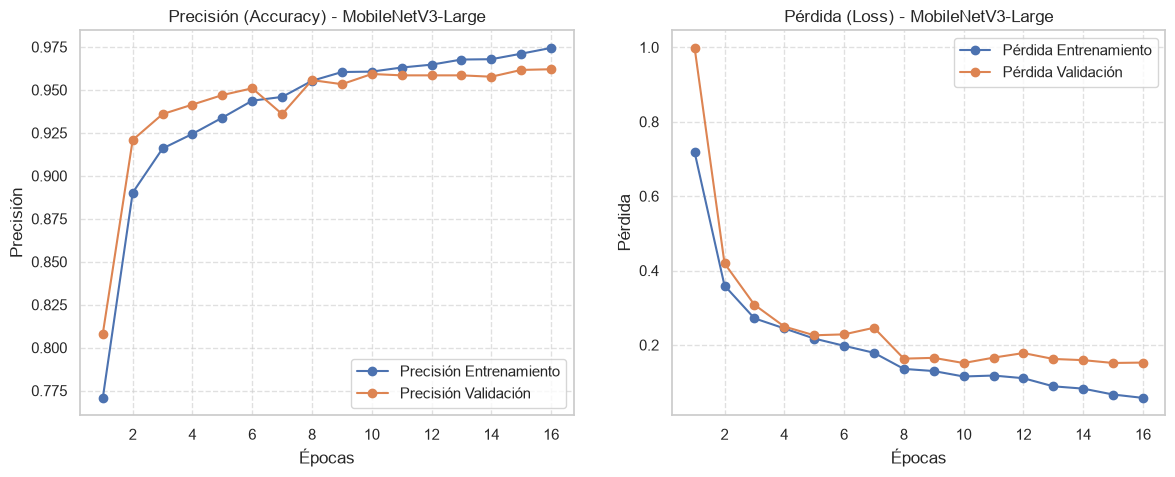

In [7]:
# Extraer datos de la versión Large
acc = history_large.history['accuracy']
val_acc = history_large.history['val_accuracy']
loss = history_large.history['loss']
val_loss = history_large.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))

# Gráfica de Precisión
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Precisión Entrenamiento', marker='o')
plt.plot(epochs_range, val_acc, label='Precisión Validación', marker='o')
plt.legend(loc='lower right')
plt.title('Precisión (Accuracy) - MobileNetV3-Large')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.grid(True, linestyle='--', alpha=0.6)

# Gráfica de Pérdida
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Pérdida Entrenamiento', marker='o')
plt.plot(epochs_range, val_loss, label='Pérdida Validación', marker='o')
plt.legend(loc='upper right')
plt.title('Pérdida (Loss) - MobileNetV3-Large')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

Cargando el MEJOR modelo Large guardado para la evaluación...
Evaluando el modelo con el conjunto de prueba (Test Dataset)...
79/79 ━━━━━━━━━━━━━━━━━━━━ 21s 223ms/step - accuracy: 0.9581 - loss: 0.1335 - precision: 0.9617 - recall: 0.9545

Resultados Finales en Test -> Precisión: 95.81% | Pérdida: 0.1335
Generando predicciones detalladas...

REPORTE DE CLASIFICACIÓN FINAL (LARGE)
                           precision    recall  f1-score   support

              aphids_pest       1.00      0.90      0.95        10
              common_rust       0.99      1.00      1.00       219
            fall_armyworm       0.96      0.95      0.96       485
           gray_leaf_spot       0.83      0.95      0.89       119
                  healthy       0.98      0.98      0.98       847
      nitrogen_deficiency       0.95      0.78      0.86        54
northern_corn_leaf_blight       0.98      0.94      0.96       714
    phosphorus_deficiency       0.88      0.96      0.92        54
     potassiu

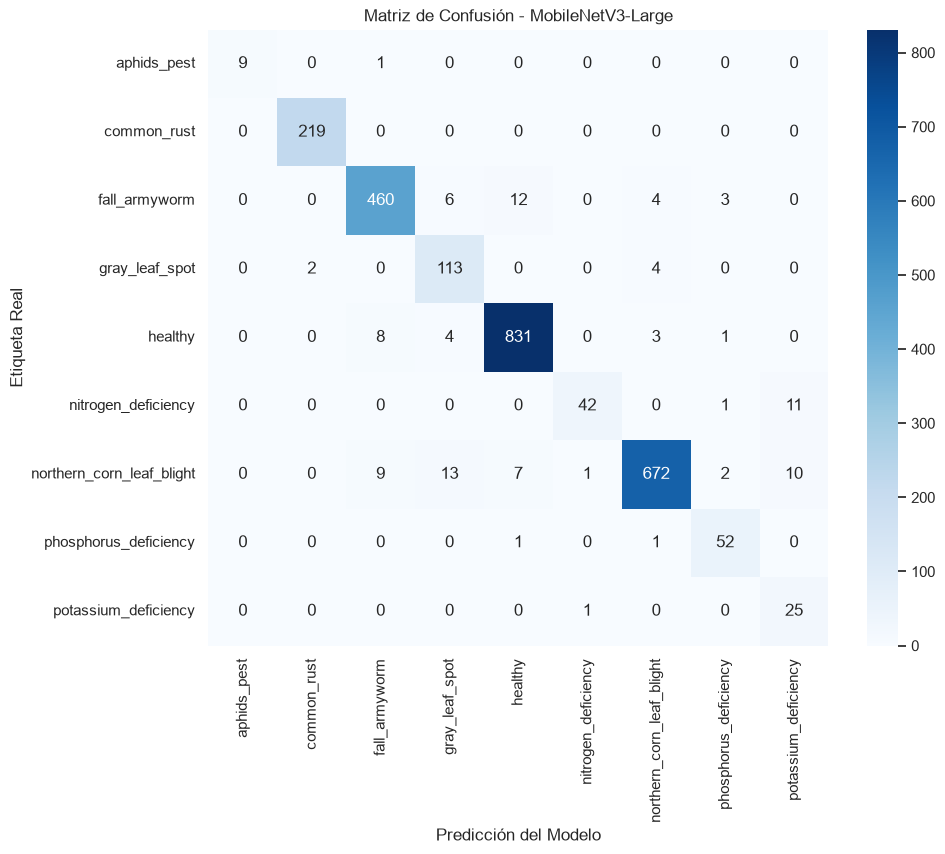

In [8]:
print("Cargando el MEJOR modelo Large guardado para la evaluación...")
mejor_modelo_large = tf.keras.models.load_model(ruta_large)

print("Evaluando el modelo con el conjunto de prueba (Test Dataset)...")
test_loss, test_acc, test_prec, test_rec = mejor_modelo_large.evaluate(test_dataset)
print(f"\nResultados Finales en Test -> Precisión: {test_acc*100:.2f}% | Pérdida: {test_loss:.4f}")

y_true = []
y_pred = []

print("Generando predicciones detalladas...")
for images, labels in test_dataset:
    preds = mejor_modelo_large.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

print("\n" + "="*50)
print("REPORTE DE CLASIFICACIÓN FINAL (LARGE)")
print("="*50)
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión - MobileNetV3-Large')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Etiqueta Real')
plt.show()

In [9]:
print("Iniciando compresión y conversión a TensorFlow Lite...")

# 1. Cargamos el modelo
modelo_final_large = tf.keras.models.load_model(ruta_large)

# 2. Configuramos el convertidor
converter = tf.lite.TFLiteConverter.from_keras_model(modelo_final_large)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model_large = converter.convert()

# 3. Guardamos el archivo .tflite
tflite_path_large = os.path.join(CARPETA_DESTINO, 'mobilenetv3_large_mejor.tflite')
with open(tflite_path_large, 'wb') as f:
    f.write(tflite_model_large)

print(f"\n ¡Éxito! Modelo comprimido (Large) listo para la web en: {tflite_path_large}")
# El diccionario de etiquetas ya se creó con el primer modelo, así que no necesitamos reescribirlo.

Iniciando compresión y conversión a TensorFlow Lite...
INFO:tensorflow:Assets written to: C:\Users\bner\AppData\Local\Temp\tmpqpzjsimm\assets


INFO:tensorflow:Assets written to: C:\Users\bner\AppData\Local\Temp\tmpqpzjsimm\assets


Saved artifact at 'C:\Users\bner\AppData\Local\Temp\tmpqpzjsimm'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 9), dtype=tf.float32, name=None)
Captures:
  2955432994448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2955432296272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2955432286096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2955432993104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2955432282832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2955445360144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2955445363024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2955445354960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2955445363216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2955445356880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  29554